In [1]:
# Imports
from scipy.io import loadmat
import pandas as pd
import numpy as np
import plotly.express as px
import torch.nn as nn
import torch
import itertools
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = loadmat('Xtrain.mat')

In [11]:
def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df/255
    return normalized
    
def slices(s: pd.Series, slice_length) -> tuple[pd.Series, pd.Series]:
    slices = [window for window in s.rolling(window=slice_length+1)]
    res = [(slc.iloc[:-1], slc.iloc[-1]) for slc in slices[slice_length:]]
    return res

def cv_split(X: np.ndarray, Y: np.ndarray, n_splits=5, gap=0) -> list[tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int, int]]:
    split_size = len(X) // n_splits
    splits = []
    for i in range(n_splits):
        start = i * split_size
        end = (i + 1) * split_size if i < n_splits - 1 else len(X)

        train_left_end = max(0, start - gap)
        train_right_start = min(len(X), end + gap)

        X_train = np.concatenate((X[:train_left_end], X[train_right_start:]), axis=0)
        Y_train = np.concatenate((Y[:train_left_end], Y[train_right_start:]), axis=0)
        X_val = X[start:end]
        Y_val = Y[start:end]
        splits.append((X_train, Y_train, X_val, Y_val, start, end))
    return splits

# def cv_split(
#     X: np.ndarray,
#     Y: np.ndarray,
#     n_splits=5,
#     gap=0,
#     val_size=None
# ):
#     n = len(X)
#     if val_size is None:
#         val_size = n // (n_splits + 1)

#     splits = []

#     for i in range(n_splits):
#         train_end = (i + 1) * val_size
#         val_start = train_end + gap
#         val_end = val_start + val_size

#         if val_end > n:
#             break

#         X_train = X[:train_end]
#         Y_train = Y[:train_end]

#         X_val = X[val_start:val_end]
#         Y_val = Y[val_start:val_end]

#         splits.append((X_train, Y_train, X_val, Y_val, train_end, val_start))

#     return splits

In [12]:
def recursive_predict(model, start_window, steps=200):
    model.eval() # set model to evaluation mode
    
    window = start_window.clone().detach() # make sure not to change orginal input
    preds = [] # predictions

    for _ in range(steps):
        with torch.no_grad():
            # LSTM expects input shape (batch_size, seq_len, features)
            pred = model(window.unsqueeze(0)) # Adds dimension to (seq_len, 1) to get correct shape: (1, seq_len, 1)
        
        preds.append(pred.item())

        # shift window
        window = torch.cat([window[1:], pred], dim=0) # removes oldest value and adds new prediction at the end

    return preds

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True # needed because we have (batch_size, seq_len, 1). So batch size is given first
        )
        
        self.fc = nn.Linear(hidden_size, 1) # Connects final layer to output

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # pass through model
        out, _ = self.lstm(x)

        # out contains hidden states for all timesteps:
        # shape: (batch_size, seq_len, hidden_size)
        
        # we only care about last timestep.
        out = out[:, -1, :] #takes last timestep
        out = self.fc(out) # gets prediction
        
        return out

In [ ]:
results = []

# how many times to repeat each config
n_runs = 5

# hyperparameters to try
window_sizes = [16, 24, 32]
hidden_sizes = [32, 64]
num_layers_list = [1, 2]
epochs_list = [500, 1000, 2000]
learning_rates = [1e-4, 5e-4, 1e-3]

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# try all combinations of hyperparameters
for window_size, hidden_size, num_layers, epochs, learning_rate in itertools.product(window_sizes, hidden_sizes, num_layers_list, epochs_list, learning_rates):

    print(f"\nRunning: window={window_size}, hidden={hidden_size}, layers={num_layers}, epochs={epochs}, learning rate={learning_rate}")

    # store results across runs
    mae_1_list, mae_200_list = [], []
    mse_1_list, mse_200_list = [], []

    # for run in range(n_runs):  # repeat training multiple times to average evaluation
    #     print(f"  Run {run + 1}/{n_runs}")

    # recreate dataset with current chosen window
    df = pd.Series(data['Xtrain'].flatten())
    df = data_cleaning(df)

    X, Y = zip(*slices(df, window_size))

    X = np.array(X).reshape(-1, window_size, 1)
    Y = np.array(Y).reshape(-1, 1)

    fold_metrics = []
    for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=5, gap=window_size), start=1):
        # Convert to PyTorch tensors
        X_train = torch.tensor(X_train, dtype=torch.float32)
        Y_train = torch.tensor(Y_train, dtype=torch.float32)
        X_val = torch.tensor(X_val, dtype=torch.float32)
        Y_val = torch.tensor(Y_val, dtype=torch.float32)

        # create model
        model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        #-------------------------------------------------
        # training
        #-------------------------------------------------
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            pred = model(X_train)
            loss = criterion(pred, Y_train)
            loss.backward()  # backpropagation
            optimizer.step()  # update parameters
        #-------------------------------------------------

        #-------------------------------------------------
        # 1-step evaluation
        #-------------------------------------------------
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val).numpy()
            y_true = Y_val.numpy()

        mae_1 = mean_absolute_error(y_true, val_pred)
        mse_1 = mean_squared_error(y_true, val_pred)
        #-------------------------------------------------

        #-------------------------------------------------
        # 200-step evaluation
        #-------------------------------------------------
        start_idx = val_start
        start_window = series_full[start_idx:start_idx + window_size]

        # determine max possible steps
        max_steps = len(series_full) - (start_idx + window_size)
        steps = min(200, max_steps)

        true_future = series_full[start_idx + window_size:start_idx + window_size + steps]  # true values

        # convert start window to tensor
        start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

        preds = recursive_predict(model, start_tensor, steps)  # predictions

        mae_200 = mean_absolute_error(true_future, preds)
        mse_200 = mean_squared_error(true_future, preds)
        #-------------------------------------------------

        fold_metrics.append((mae_1, mse_1, mae_200, mse_200))

    fold_metrics = np.array(fold_metrics)
    mae_1_list.append(fold_metrics[:, 0].mean())
    mse_1_list.append(fold_metrics[:, 1].mean())
    mae_200_list.append(fold_metrics[:, 2].mean())
    mse_200_list.append(fold_metrics[:, 3].mean())

    #-------------------------------------------------
    # store results
    #-------------------------------------------------
    results.append({
        "window": window_size,
        "hidden": hidden_size,
        "layers": num_layers,
        "epochs": epochs,
        "learning_rate": learning_rate,

        "mae_1_mean": np.mean(mae_1_list),
        "mae_1_std": np.std(mae_1_list),

        "mae_200_mean": np.mean(mae_200_list),
        "mae_200_std": np.std(mae_200_list),

        "mse_1_mean": np.mean(mse_1_list),
        "mse_200_mean": np.mean(mse_200_list)
    })
    #-------------------------------------------------

    print(f"Avg 1-step MAE: {np.mean(mae_1_list):.4f} +- {np.std(mae_1_list):.4f}")
    print(f"Avg 200-step MAE: {np.mean(mae_200_list):.4f} +- {np.std(mae_200_list):.4f}")

#-------------------------------------------------
# sort best models
results_sorted = sorted(results, key=lambda x: x["mae_200_mean"] + x["mae_200_std"] )

print("\nTop 5 models (based on mean 200-step MAE):")
for r in results_sorted[:5]:
    print(r)


Running: window=16, hidden=32, layers=1, epochs=500, learning rate=0.0001
Avg 1-step MAE: 0.1444 +- 0.0000
Avg 200-step MAE: 0.1449 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=500, learning rate=0.0005
Avg 1-step MAE: 0.0623 +- 0.0000
Avg 200-step MAE: 0.1389 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=500, learning rate=0.001
Avg 1-step MAE: 0.0314 +- 0.0000
Avg 200-step MAE: 0.1245 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=1000, learning rate=0.0001
Avg 1-step MAE: 0.0857 +- 0.0000
Avg 200-step MAE: 0.1333 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=1000, learning rate=0.0005
Avg 1-step MAE: 0.0207 +- 0.0000
Avg 200-step MAE: 0.1062 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=1000, learning rate=0.001
Avg 1-step MAE: 0.0218 +- 0.0000
Avg 200-step MAE: 0.1133 +- 0.0000

Running: window=16, hidden=32, layers=1, epochs=2000, learning rate=0.0001
Avg 1-step MAE: 0.0554 +- 0.0000
Avg 200-step MAE: 0.1569 +- 0.00

KeyboardInterrupt: 


Fold 1: Validate on [0:133]

1-step MAE: 0.0201 +- 0.0000

1-step MSE: 0.0035 +- 0.0000

200-step MAE: 0.0491 +- 0.0000

200-step MSE: 0.0074 +- 0.0000


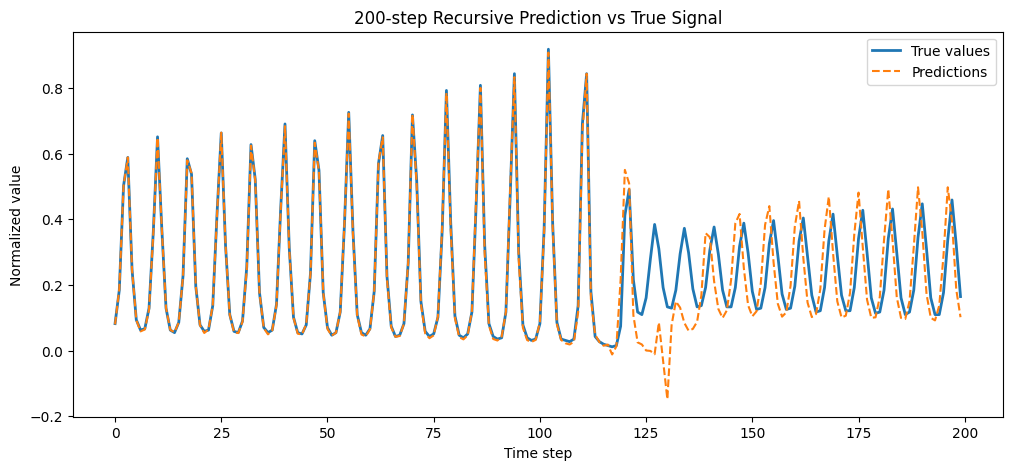


Fold 2: Validate on [133:266]

1-step MAE: 0.0153 +- 0.0047

1-step MSE: 0.0018 +- 0.0016

200-step MAE: 0.1114 +- 0.0623

200-step MSE: 0.0327 +- 0.0253


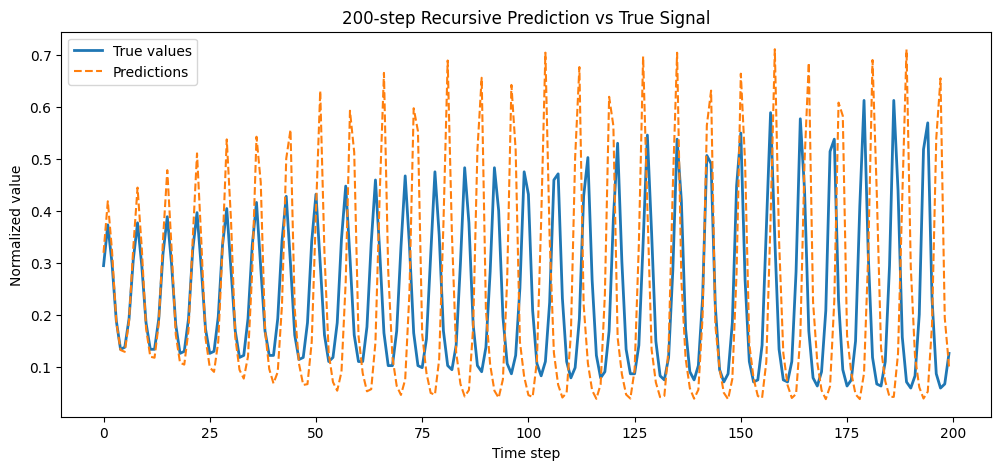


Fold 3: Validate on [266:399]

1-step MAE: 0.0109 +- 0.0073

1-step MSE: 0.0012 +- 0.0016

200-step MAE: 0.1013 +- 0.0528

200-step MSE: 0.0310 +- 0.0207


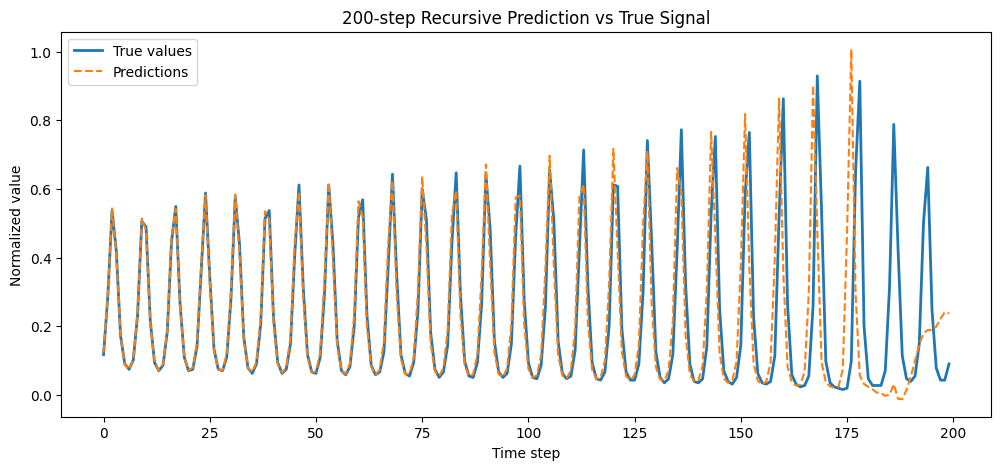


Fold 4: Validate on [399:532]

1-step MAE: 0.0246 +- 0.0245

1-step MSE: 0.0055 +- 0.0075

200-step MAE: 0.1147 +- 0.0513

200-step MSE: 0.0347 +- 0.0191


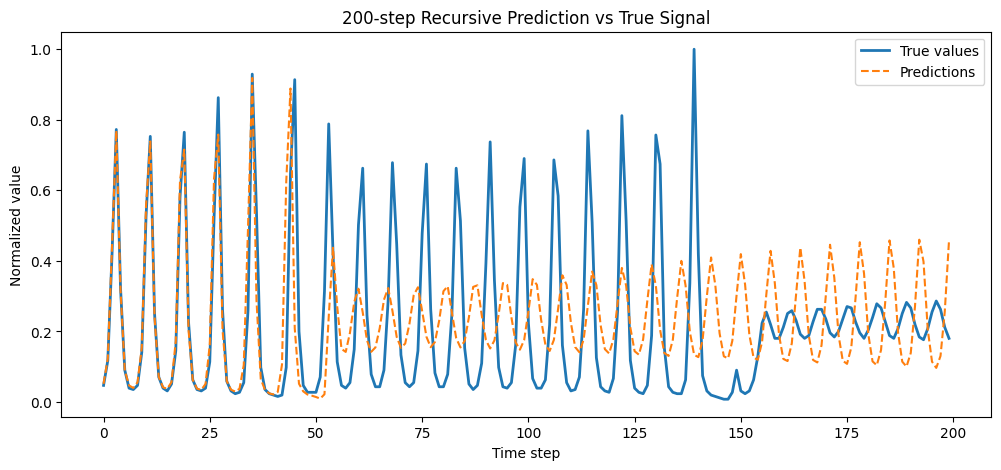


Fold 5: Validate on [532:665]

1-step MAE: 0.0254 +- 0.0220

1-step MSE: 0.0059 +- 0.0068

200-step MAE: 0.1195 +- 0.0469

200-step MSE: 0.0338 +- 0.0171


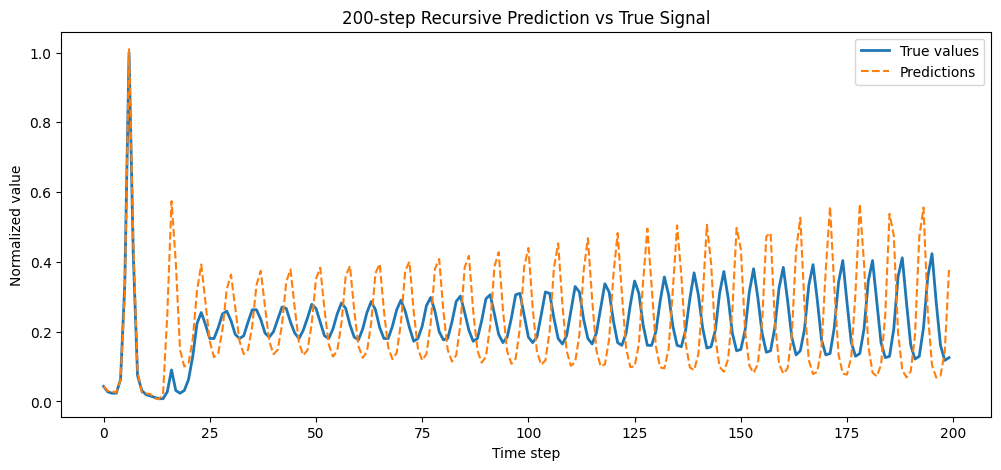


Fold 6: Validate on [665:798]

1-step MAE: 0.0222 +- 0.0213

1-step MSE: 0.0050 +- 0.0066

200-step MAE: 0.1025 +- 0.0572

200-step MSE: 0.0284 +- 0.0199


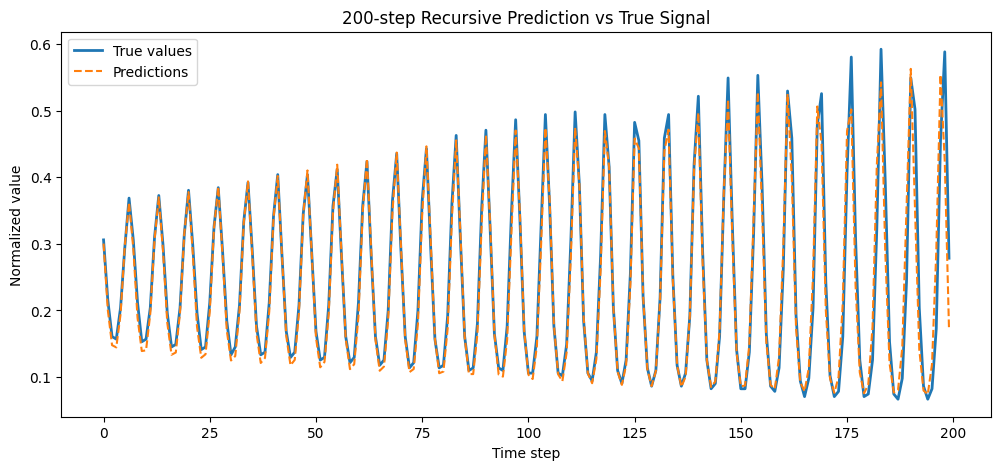


Fold 7: Validate on [798:936]

1-step MAE: 0.0195 +- 0.0208

1-step MSE: 0.0043 +- 0.0063

200-step MAE: 0.0916 +- 0.0594

200-step MSE: 0.0246 +- 0.0206


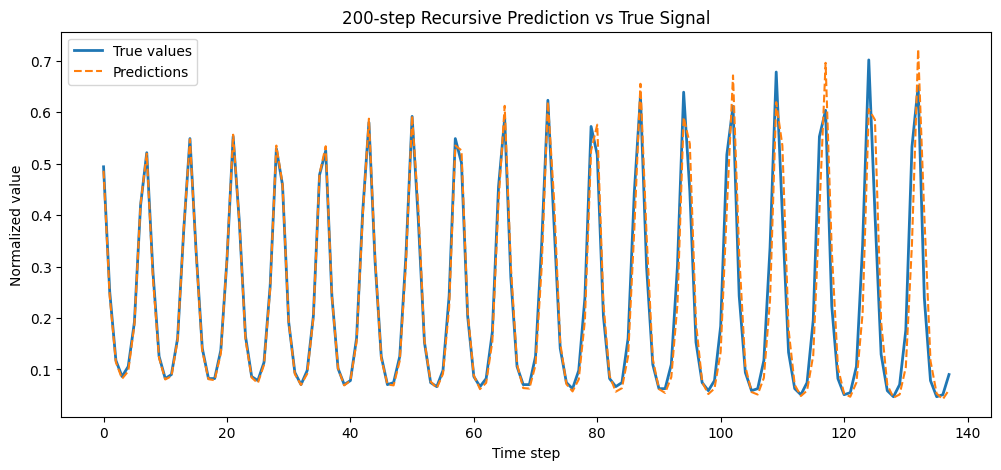

In [18]:
# hyperparameters
window_size = 64
hidden_size = 128
num_layers = 2
epochs = 2000
learning_rate = 1e-3
#---------------------------------------------------

# create data
series_full = pd.Series(data['Xtrain'].flatten())
series_full = data_cleaning(series_full).values

# recreate dataset with current chosen window
df = pd.Series(data['Xtrain'].flatten())
df = data_cleaning(df)

X, Y = zip(*slices(df, window_size))

X = np.array(X).reshape(-1, window_size, 1)
Y = np.array(Y).reshape(-1, 1)

# use cross validation
fold_results = []
for fold_idx, (X_train, Y_train, X_val, Y_val, val_start, val_end) in enumerate(cv_split(X, Y, n_splits=7, gap=window_size), start=1):
    print(f"\nFold {fold_idx}: Validate on [{val_start}:{val_end}]")
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    Y_train = torch.tensor(Y_train, dtype=torch.float32)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    Y_val = torch.tensor(Y_val, dtype=torch.float32)

    # create model
    model = LSTMModel(hidden_size=hidden_size, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    #-------------------------------------------------
    # training
    #-------------------------------------------------
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = criterion(pred, Y_train)
        loss.backward()  # backpropagation
        optimizer.step()  # update parameters
    #-------------------------------------------------

    #-------------------------------------------------
    # 1-step evaluation
    #-------------------------------------------------
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val).numpy()
        y_true = Y_val.numpy()

    mae_1 = mean_absolute_error(y_true, val_pred)
    mse_1 = mean_squared_error(y_true, val_pred)
    #-------------------------------------------------

    #-------------------------------------------------
    # 200-step evaluation
    #-------------------------------------------------
    start_idx = val_start
    start_window = series_full[start_idx:start_idx + window_size]

    # determine max possible steps
    max_steps = len(series_full) - (start_idx + window_size)
    steps = min(200, max_steps)

    true_future = series_full[start_idx + window_size:start_idx + window_size + steps]  # true values

    # convert start window to tensor
    start_tensor = torch.tensor(start_window.reshape(window_size, 1), dtype=torch.float32)

    preds = recursive_predict(model, start_tensor, steps)  # predictions

    mae_200 = mean_absolute_error(true_future, preds)
    mse_200 = mean_squared_error(true_future, preds)
    #-------------------------------------------------

    fold_results.append({
        "fold": fold_idx,
        "mae_1": mae_1,
        "mse_1": mse_1,
        "mae_200": mae_200,
        "mse_200": mse_200,
    })

    mae_1_values = [item["mae_1"] for item in fold_results]
    mse_1_values = [item["mse_1"] for item in fold_results]
    mae_200_values = [item["mae_200"] for item in fold_results]
    mse_200_values = [item["mse_200"] for item in fold_results]

    print(f"\n1-step MAE: {np.mean(mae_1_values):.4f} +- {np.std(mae_1_values):.4f}")
    print(f"\n1-step MSE: {np.mean(mse_1_values):.4f} +- {np.std(mse_1_values):.4f}")
    print(f"\n200-step MAE: {np.mean(mae_200_values):.4f} +- {np.std(mae_200_values):.4f}")
    print(f"\n200-step MSE: {np.mean(mse_200_values):.4f} +- {np.std(mse_200_values):.4f}")

    #-----------------------
    # plot
    #-----------------------
    import matplotlib.pyplot as plt

    # Create x-axis (time steps)
    t = range(len(true_future))

    plt.figure(figsize=(12, 5))

    # True signal
    plt.plot(t, true_future, label="True values", linewidth=2)

    # Predicted signal
    plt.plot(t, preds, label="Predictions", linestyle='--')

    plt.title("200-step Recursive Prediction vs True Signal")
    plt.xlabel("Time step")
    plt.ylabel("Normalized value")
    plt.legend()

    plt.show()
